In [1]:
from scipy.integrate import solve_ivp
from scipy.integrate import trapz
import matplotlib.pyplot as plt
import numpy as np

In [2]:
### Initial Conditions and Parameters ### 
# b = Births  
# d = Deaths  
# Beta = Transmission rate  
# delta = Death due to disease 
# a = Maximum predation rate
# g = Half-saturation constant
# c = Amount of predator preference for infected individuals

initial_y0 = [100, 1] # (S0, I0)
b = 10
Beta = 2
delta = 5
a = 20
g = 100
d = a/g
c = 1

## Linear Predation

In [3]:
# Define dS/dt and dI/dt
# y is the vector [S,I], t is time

def deriv_y_lin(t,y,b,d,Beta,delta):
  S, I = y
  dS = b - d*S - Beta*I*S
  dI = Beta*I*S - d*I - delta*I
  return [dS,dI]

In [ ]:
# The solver_constant functions take an initial condition and set of parameters and integrate
# the ODEs associated with the constant birth models. solver_constant_lin is for the linear predation 
# model and solver_constant_hyp is for the hyperbolic predation model. It first integrates for 250 years to 
# avoid transient behavior and then integrates for an additional 10 years. It returns the solution for the 
# susceptible and infected populations over the 10 years and the corresponding time points.
# Note: the range for t and time must match

def solver_constant_lin(IC, b, d, Beta, delta):
    for i in range(0,2):
        if i == 0:
            t = np.linspace(0,250,200) 
            time = [0,250]
            y0 = IC
        else:
            t = np.linspace(0,10,1000) # times to integrate for: t=0 to t=10 years, 1000 time points in range
            time = [0,10]
            y0 = [S[-1],I[-1]] # use number of susceptibles and infecteds from the end of the first integration as the new initial conditions
        ysol = solve_ivp(deriv_y_lin,time,y0,method='RK45',args=(b,d,Beta,delta),dense_output=True, rtol = 1e-13, atol = 1e-323)
        S,I=ysol.sol(t)
    return [S,I,t]

In [12]:
# Calculate the average number of infected individuals for one year
    
result = solver_constant_lin(initial_y0, b, d, Beta, delta)
avg_infect = trapz(result[1],result[2])*(1/max(result[2]))
print('Average infected for constant births: '+str(round(avg_infect, 3)))

Average infected for constant births: 1.823


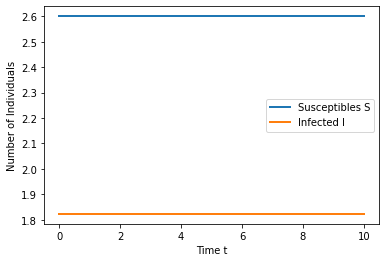

In [10]:
# Plot susceptibles and infecteds versus time

plt.plot(result[2],result[0],linewidth=2,label='Susceptibles S')
plt.plot(result[2],result[1],linewidth=2,label='Infected I')
plt.xlabel('Time t')
plt.ylabel('Number of Individuals')
plt.legend()
plt.show()

## Hyperbolic Predation

Average infected for constant births: 1.83


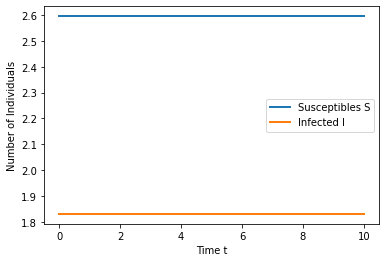

In [13]:
def deriv_y_hyp(t,y,b,Beta,delta,a,g,c):
  S, I = y
  dS = b - Beta*I*S - a*S/(g+S+c*I)
  dI = Beta*I*S - delta*I - a*c*I/(g+S+c*I)
  return [dS,dI]

def solver_constant_hyp(IC, b, Beta, delta, a, g, c):
    for i in range(0,2):
        if i == 0:
            t = np.linspace(0,250,200)
            time = [0,250]
            y0 = IC
        else:
            t = np.linspace(0,10,1000)
            time = [0,10]
            y0 = [S[-1],I[-1]]
        ysol = solve_ivp(deriv_y_hyp,time,y0,method='RK45',args=(b,Beta,delta,a,g,c),dense_output=True, rtol = 1e-13, atol = 1e-323)
        S,I=ysol.sol(t)
    return [S,I,t]

result = solver_constant_hyp(initial_y0, b, Beta, delta, a, g, c)
avg_infect = trapz(result[1],result[2])*(1/max(result[2]))
print('Average infected for constant births: '+str(round(avg_infect, 3)))

plt.plot(result[2],result[0],linewidth=2,label='Susceptibles S')
plt.plot(result[2],result[1],linewidth=2,label='Infected I')
plt.xlabel('Time t')
plt.ylabel('Number of Individuals')
plt.legend()
plt.show()